In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("powerplant_data.csv")
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [3]:
x=df.drop("PE",axis=1)
y=df["PE"]

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [8]:
import torch
import torch.nn as nn

In [9]:
x_train_tensor=torch.tensor(x_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

In [11]:
x_test_tensor=torch.tensor(x_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [12]:
from torch.utils.data import TensorDataset,DataLoader


In [13]:
train_dataset=TensorDataset(x_train_tensor,y_train_tensor)
test_dataset=TensorDataset(x_test_tensor,y_test_tensor)

In [14]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)

In [15]:
#define ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
            #1st hidden layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),
            #2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
            #outputlayer
            nn.Linear(6,1),)
    def forward(self,x):
        return self.model(x)
    
    
    

In [16]:
import torch.optim as optim
model=ANN()
crietrion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [21]:
#Train the ANN
train_losses=[]
val_losses=[]
epochs=100
for epoch in range(epochs):
    model.train()
    running_loss=0.0

    for xb,yb in train_loader:
        optimizer.zero_grad()
        outputs=model(xb)
        loss=crietrion(outputs,yb)
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()

    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    running_val_loss=0.0
    with torch.no_grad():
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=crietrion(outputs,yb)
            running_val_loss+=loss

    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch{epoch+1}/{epochs}==>train_loss={epoch_train_loss} && val_loss={epoch_val_loss}")
        

epoch1/100==>train_loss=20.736686404546102 && val_loss=19.73668098449707
epoch2/100==>train_loss=20.9717236995697 && val_loss=18.923839569091797
epoch3/100==>train_loss=20.738344554106394 && val_loss=19.175395965576172
epoch4/100==>train_loss=20.970226609706877 && val_loss=18.98029136657715
epoch5/100==>train_loss=20.754857720931373 && val_loss=19.149120330810547
epoch6/100==>train_loss=20.815436629454293 && val_loss=18.861854553222656
epoch7/100==>train_loss=20.733643496036528 && val_loss=18.94599723815918
epoch8/100==>train_loss=20.681225073337554 && val_loss=19.353975296020508
epoch9/100==>train_loss=20.774824468294778 && val_loss=19.315805435180664
epoch10/100==>train_loss=20.75605567296346 && val_loss=18.907489776611328
epoch11/100==>train_loss=20.78603343566259 && val_loss=19.06369972229004
epoch12/100==>train_loss=20.8089284102122 && val_loss=18.845905303955078
epoch13/100==>train_loss=20.611545343200365 && val_loss=19.381099700927734
epoch14/100==>train_loss=20.800335264205934 

In [22]:
import matplotlib.pyplot as plt

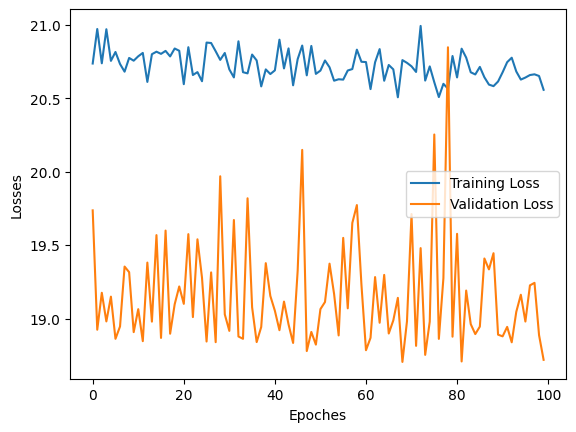

In [23]:
loss_df=pd.DataFrame({
    "training loss":train_losses,
    "validation loss":val_losses})
plt.plot(loss_df["training loss"],label="Training Loss")
plt.plot(loss_df["validation loss"],label="Validation Loss")
plt.xlabel("Epoches")
plt.ylabel("Losses")
plt.legend()

In [29]:
#Evaluation
model.eval()
with torch.no_grad():
    train_preds=model(x_train_tensor)
    test_preds=model(x_test_tensor)

    train_mse_loss=crietrion(train_preds,y_train_tensor)
    test_mse_loss=crietrion(test_preds,y_test_tensor)

print("training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

training MSE: 20.4279727935791
Testing MSE: 18.722740173339844


In [30]:
from sklearn.metrics import r2_score
print("r2_score",r2_score(y_test,test_preds))

predicted_df=pd.DataFrame(test_preds.numpy(),columns=["predicted values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual Values"])
pd.concat([predicted_df,actual_df],axis=1)

r2_score 0.9345688497865697


,predicted values,Actual Values
0,435.393799,433.27
1,436.838196,438.16
2,461.148438,458.42
3,475.924438,480.82
4,435.446259,441.41
...,...,...
1909,451.190186,456.70
1910,431.665283,438.04
1911,467.503601,467.80
1912,431.086365,437.14
